In [160]:
#Core 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [161]:
df = pd.read_csv("Housing.csv")

print("---------------shape of the dataset------------------------")
print(f' Dataset : {df.shape[0]} rows X {df.shape[1]} columns')
print("___________________overview of Dataset__________________________")
info_df = pd.DataFrame({
    "dtypes" : df.dtypes,
    "not_null": df.notnull().sum(),
    "null_values": df.isnull().sum(),
    "null_%": (df.isnull().mean()*100).round(2),
    'unique': df.nunique()
})
display(info_df)
print('________________few rows of Dataset_______________')
display(df.head(10))

---------------shape of the dataset------------------------
 Dataset : 545 rows X 13 columns
___________________overview of Dataset__________________________


,dtypes,not_null,null_values,null_%,unique
price,int64,545,0,0.0,219
area,int64,545,0,0.0,284
bedrooms,int64,545,0,0.0,6
bathrooms,int64,545,0,0.0,4
stories,int64,545,0,0.0,4
mainroad,object,545,0,0.0,2
guestroom,object,545,0,0.0,2
basement,object,545,0,0.0,2
hotwaterheating,object,545,0,0.0,2
airconditioning,object,545,0,0.0,2


________________few rows of Dataset_______________


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [162]:
# Dataset Analysis:
# Categroical_binary_noncoded : ['mainroad', 'guestroom', 'guestroom', 'hotwaterheating','airconditioning','perfarea']
# Categorical_mulit_noncoded : ['furnished']
# categorical_numerical_multi : ['bedrooms',bathrooms, sotries, parking]
# numerical : [area, price]
df_clean = df.copy()

In [163]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,545.0,4.766729e+06,1.870440e+06,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,5.150541e+03,2.170141e+03,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,2.965138e+00,7.380639e-01,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,1.286239e+00,5.024696e-01,1.0,1.0,1.0,2.0,4.0
stories,545.0,1.805505e+00,8.674925e-01,1.0,1.0,2.0,2.0,4.0
parking,545.0,6.935780e-01,8.615858e-01,0.0,0.0,0.0,1.0,3.0


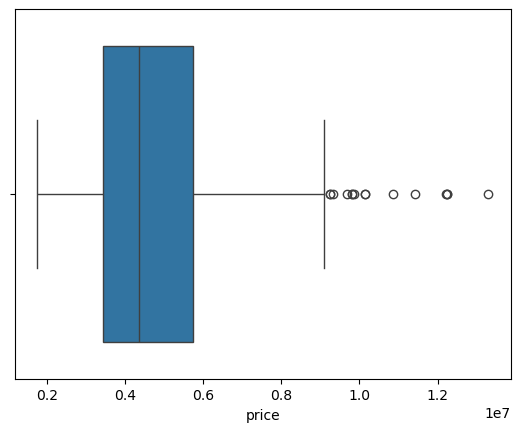

In [164]:
sns.boxplot(data = df_clean, x = 'price')
plt.show()

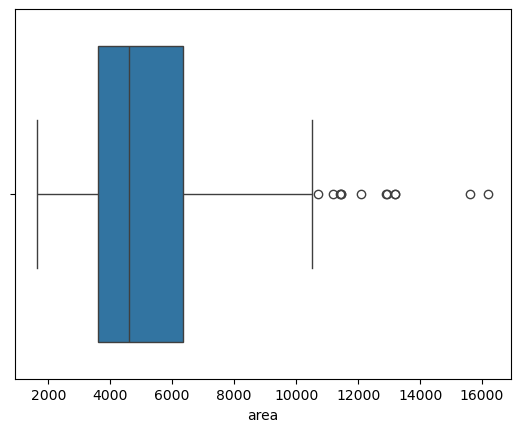

In [165]:
sns.boxplot(data = df_clean , x = 'area')
plt.show()

In [166]:
columns = ['price', 'area']
for col in columns:
    q1,q3 = df_clean[col].quantile([0.01, 0.97])
    df_clean[col] = df_clean[col].clip(lower=q1, upper=q3)

print(f' Dataset shape : {df.shape[0]} rows X {df.shape[1]} columns')

 Dataset shape : 545 rows X 13 columns


C:\Users\kisho\AppData\Local\Temp\ipykernel_17352\4010064682.py:4: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean[col] = df_clean[col].clip(lower=q1, upper=q3)


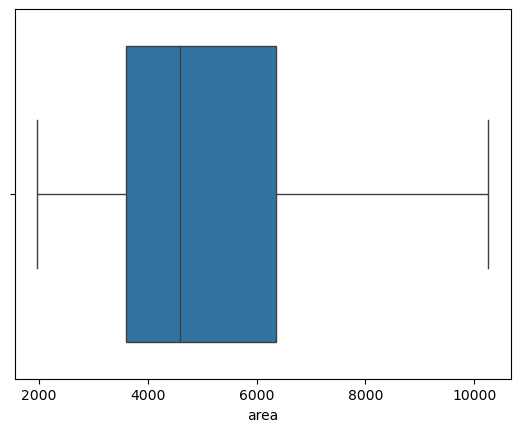

In [167]:
sns.boxplot(data = df_clean , x = 'area')
plt.show()

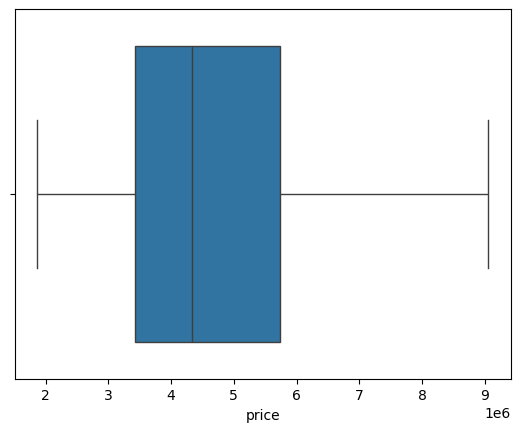

In [168]:
sns.boxplot(data = df_clean, x = 'price')
plt.show()

In [169]:
df_clean['price'] = np.log1p(df_clean['price'])
df_clean['area'] = np.log1p(df_clean['area'])

In [170]:
features = ['mainroad', 'guestroom', 'hotwaterheating','airconditioning','prefarea','furnishingstatus','basement',]

Encoder = LabelEncoder()
for feature in features:
    df_clean[feature] = Encoder.fit_transform(df_clean[feature])

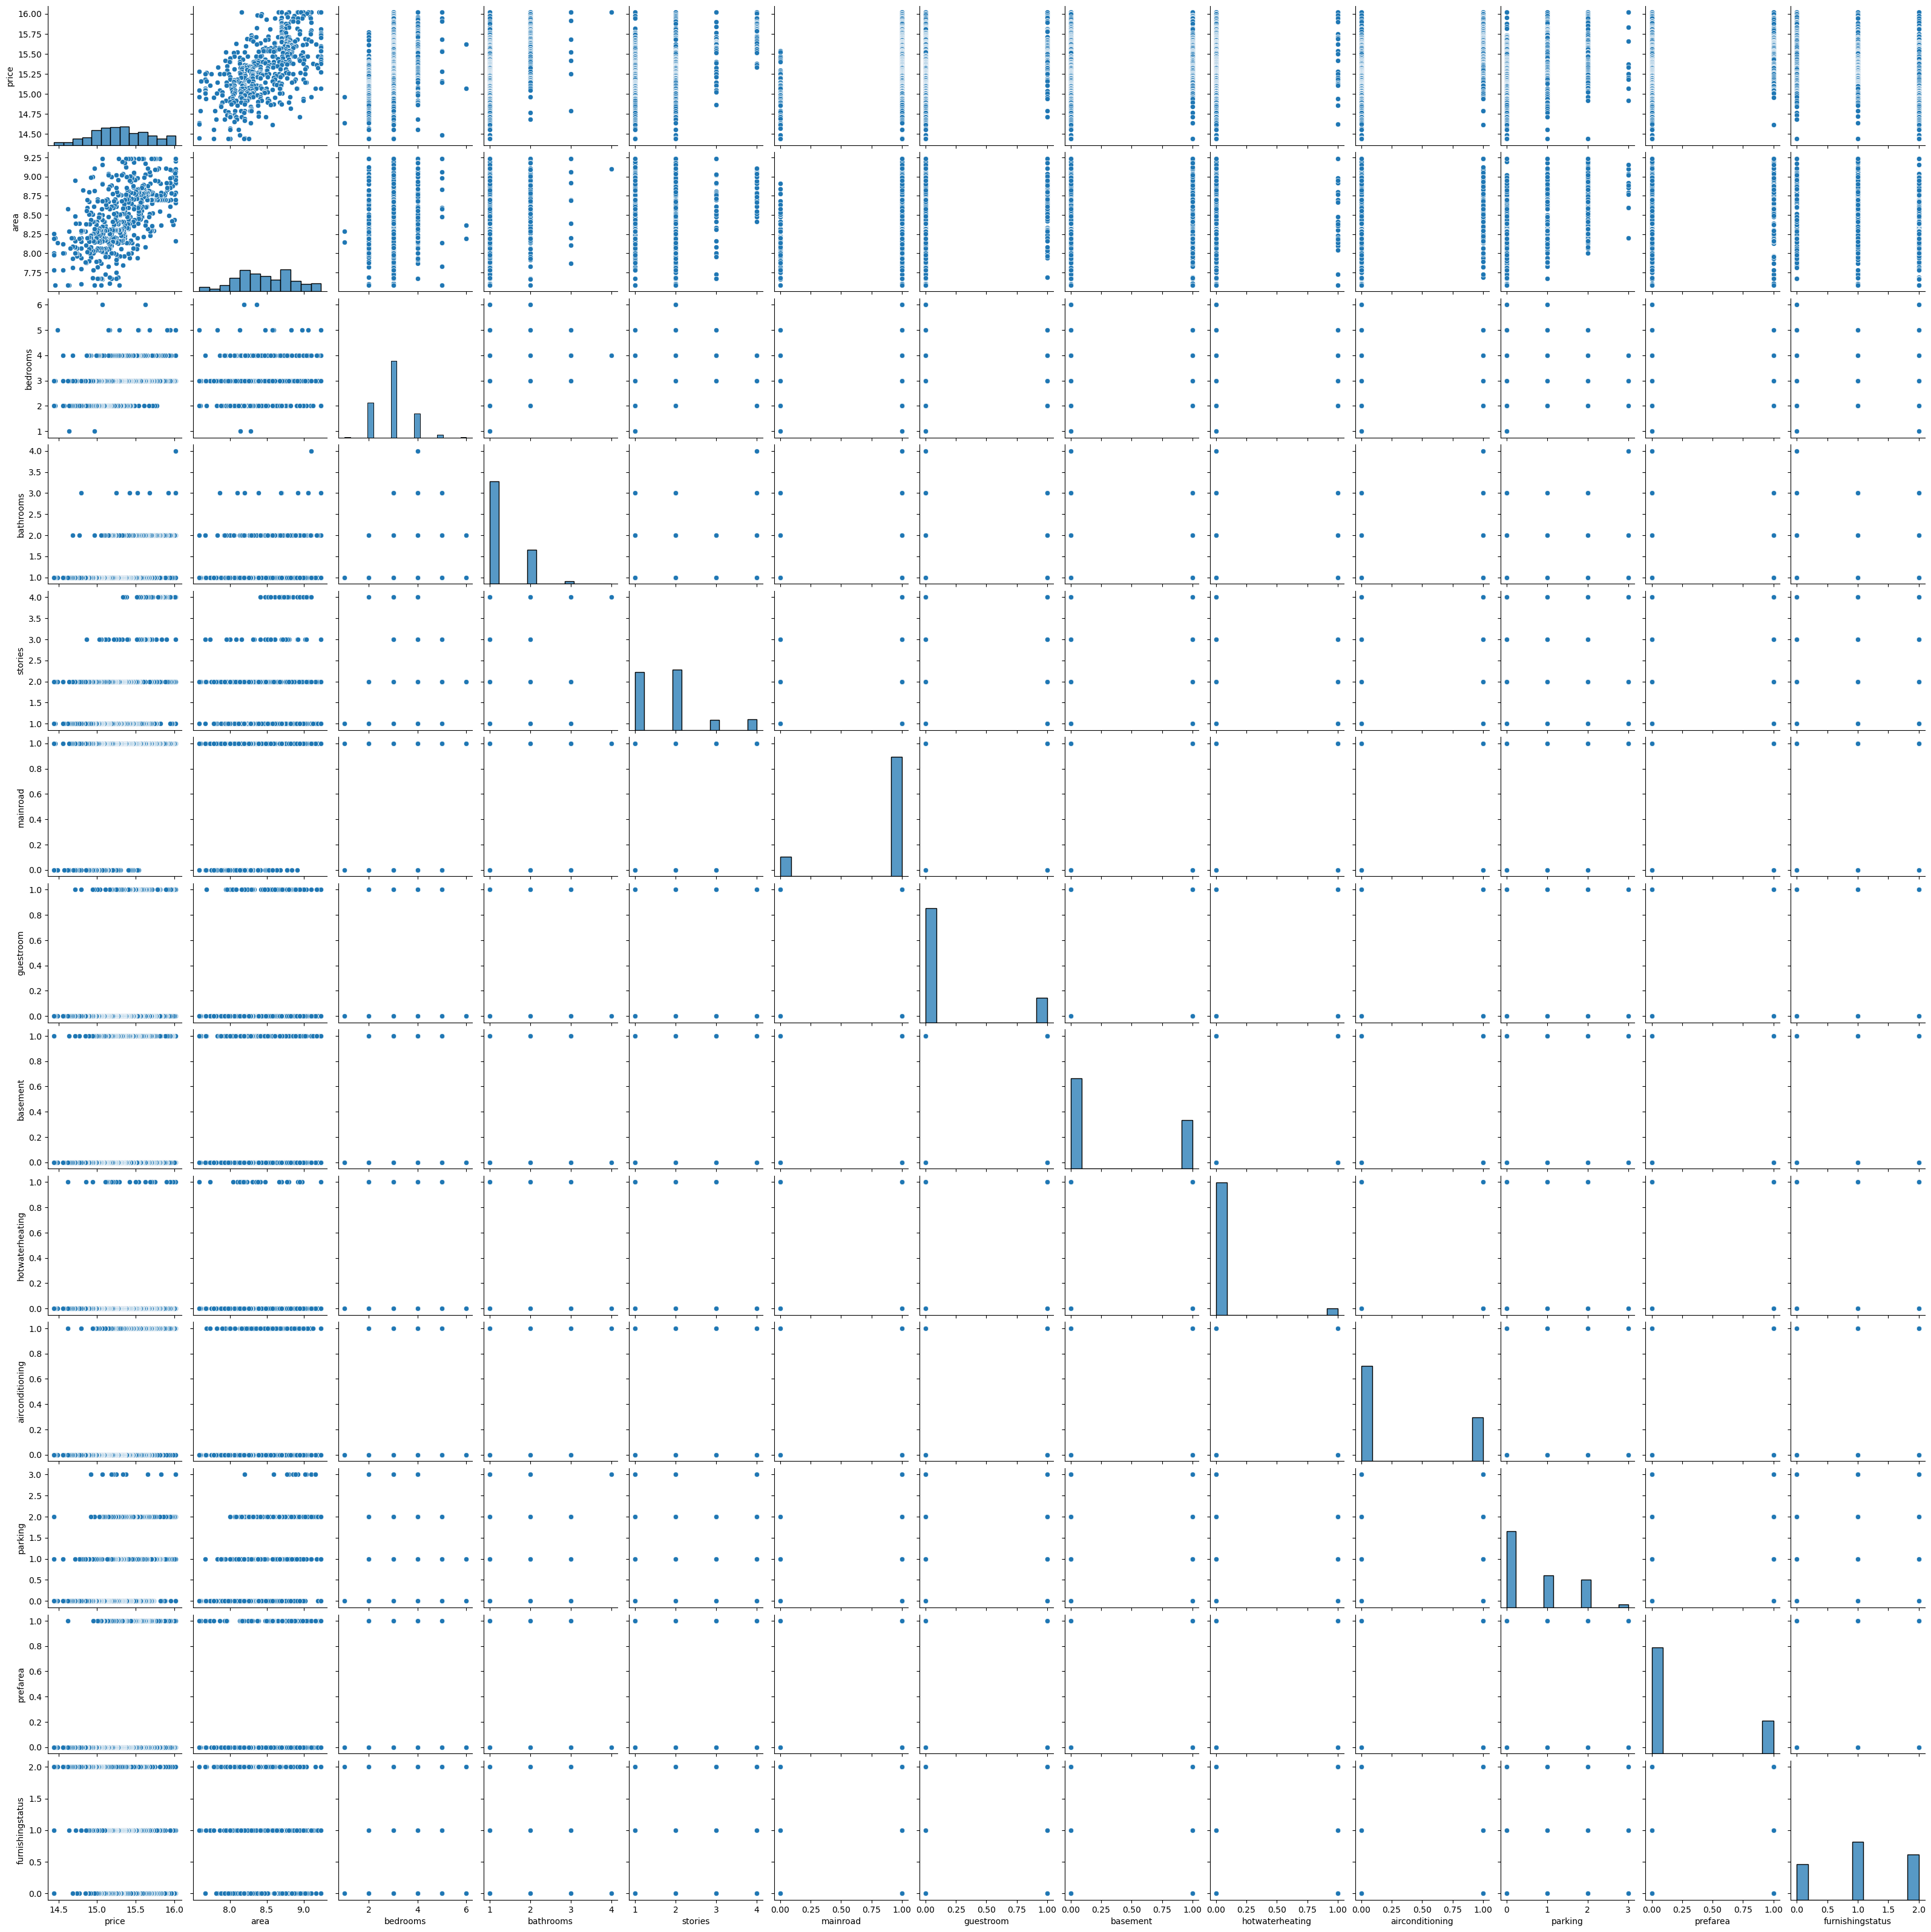

In [171]:
sns.pairplot(data =df_clean)
plt.show()

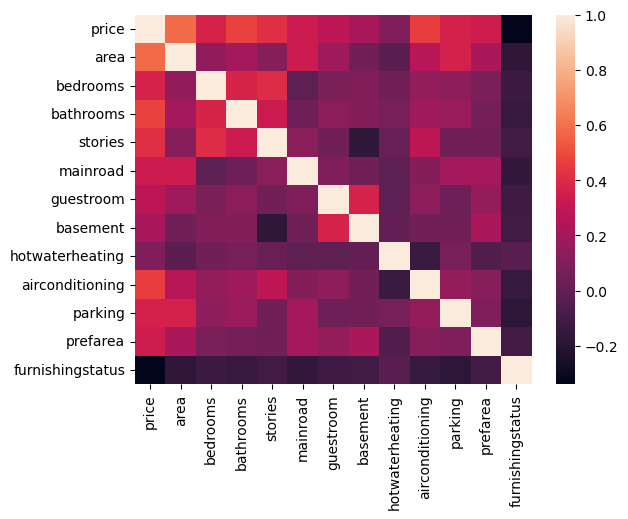

In [172]:
sns.heatmap(data = df_clean.corr())
plt.show()

In [173]:
df_clean.dtypes

price               float64
area                float64
bedrooms              int64
bathrooms             int64
stories               int64
mainroad              int64
guestroom             int64
basement              int64
hotwaterheating       int64
airconditioning       int64
parking               int64
prefarea              int64
furnishingstatus      int64
dtype: object

In [174]:
# feature engineering:
df_clean['bedrooms'] = df_clean['bedrooms'] + df_clean['guestroom']

In [175]:
df_clean['bedrooms']

0      4
1      4
2      3
3      4
4      5
      ..
540    2
541    3
542    2
543    3
544    3
Name: bedrooms, Length: 545, dtype: int64

In [176]:
df_clean.drop(columns = ['guestroom','furnishingstatus','hotwaterheating'], inplace = True)

In [177]:
X = df_clean.drop(columns = ['price'])
y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

Scaler = StandardScaler()
X_train_scaled = Scaler.fit_transform(X_train)
X_test_scaled =  Scaler.transform(X_test)

In [198]:
Linear_regression = LinearRegression().fit(X_train_scaled, y_train)
Decision_tree = DecisionTreeRegressor().fit(X_train_scaled, y_train)
Support_vector = SVR(C=10, epsilon = 0.1, kernel = 'linear').fit(X_train_scaled, y_train)
KNN = KNeighborsRegressor(n_neighbors=5,).fit(X_train_scaled, y_train)
Random_forest = RandomForestRegressor(n_estimators=200, max_depth=7,max_features = 'sqrt', min_samples_split=2,min_samples_leaf=1).fit(X_train_scaled, y_train)

In [199]:
models = [Linear_regression, Decision_tree, Support_vector, KNN, Random_forest]
results = []

for model in models:
    y_pred = model.predict(X_test_scaled)
    results.append({
        "Model":model.__class__.__name__,
    "MAE": (mean_absolute_error(y_test, y_pred)),
    "MSE": (mean_squared_error(y_test, y_pred)),
    "R2_score": (r2_score(y_test, y_pred)),
    "RMSE": (np.sqrt(mean_squared_error(y_test, y_pred)))
    })

results_df = pd.DataFrame(results)
results_df

,Model,MAE,MSE,R2_score,RMSE
0,LinearRegression,0.203337,0.065923,0.625337,0.256756
1,DecisionTreeRegressor,0.227372,0.084331,0.520722,0.290398
2,SVR,0.202289,0.065452,0.628014,0.255837
3,KNeighborsRegressor,0.213186,0.077857,0.557513,0.279029
4,RandomForestRegressor,0.207931,0.069209,0.606665,0.263076


In [191]:
#HyperParametere Tunning :

In [192]:


# 1. Define SVR specific parameters
svr_param_grid = {
    'C': [0.1, 1, 10, 100],          # Penalty parameter for error margin
    'epsilon': [0.01, 0.1, 0.2, 0.5], # Defines the width of the no-penalty tube
    'kernel': ['rbf', 'linear']      # Tests both linear and non-linear patterns
}

# 2. Setup Grid Search optimized for R2 Score
svr_grid = GridSearchCV(
    estimator=Support_vector,
    param_grid=svr_param_grid,
    cv=5,
    scoring='r2',                    # Optimizing for the highest R2 score
    n_jobs=-1
)

# 3. Fit to scaled training data
svr_grid.fit(X_train_scaled, y_train)

print("--- SVR Tuning Results ---")
print(f"Best Params: {svr_grid.best_params_}")
print(f"Best CV R2 Score: {svr_grid.best_score_:.4f}")


--- SVR Tuning Results ---
Best Params: {'C': 10, 'epsilon': 0.1, 'kernel': 'linear'}
Best CV R2 Score: 0.6639


In [193]:


# 1. Define parameters to control overfitting
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None],       # Lower depths prevent overfitting
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None] # Limits features per split
}

# 2. Setup Grid Search
rf_grid = GridSearchCV(
    estimator=Random_forest,
    param_grid=rf_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# 3. Fit to training data
rf_grid.fit(X_train_scaled, y_train)

print("\n--- Random Forest Tuning Results ---")
print(f"Best Params: {rf_grid.best_params_}")
print(f"Best CV R2 Score: {rf_grid.best_score_:.4f}")



--- Random Forest Tuning Results ---
Best Params: {'max_depth': 7, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
Best CV R2 Score: 0.6459
